# Trabajo Práctico 1 — Aprendizaje Profundo
### Carrera de Especialización en Inteligencia Artificial (CEIA)
### Facultad de Ingeniería — Universidad de Buenos Aires (FIUBA)

---

**Alumnos:**
- María Gabriela Di Grazia  — A2517
- Byron Isaac García Miranda — A2524

**Cohorte:** 25Co2026

---

In [1]:
#Agregar librerias necesarias.

import numpy as np
import matplotlib.pyplot as plt

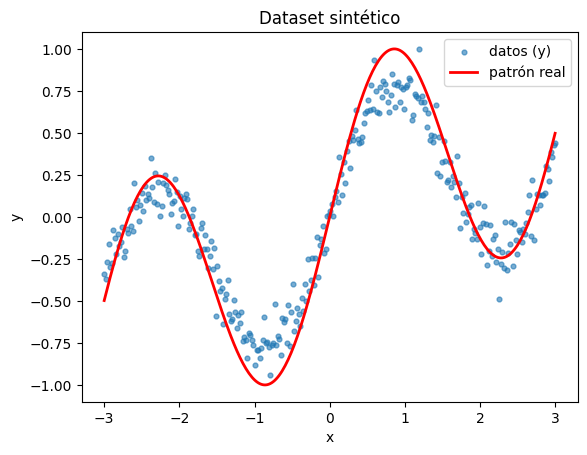

In [2]:
#Ahora bien empezamos creando los datos de entrada
np.random.seed(42)
n = 300
x = np.linspace(-3,3, n)


#Agregamos el patron no lineal 
patron = np.sin(2 * x) + 0.3 * x
ruido = np.random.normal(0, 0.15, size=n)
y = patron + ruido

#Para que pueda ser producible necesitamos que esté entre ~[-1, 1], entonces necesitamos reescalar
y = y / np.max(np.abs(y))


#grafico para entender lo que se ha hecho
plt.scatter(x, y, s=12, alpha=0.6, label="datos (y)")
plt.plot(x, patron / np.max(np.abs(patron)), 'r-', lw=2, label="patrón real")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Dataset sintético")
plt.show()

## Funciones base del modelo

Aquí haremos 3 partes claves del modelo para avanzar, y las piezas claves son:

- forward, el modelo hace su predicción
- J_mse, cuando nos referimos al cálculo del error
- grad, es el cálculo de la corrección

Con esto, el modelo predice con ŷ = tanh(wx + b). Estas funciones se usan una tras otra: se predice → se mide el error → se corrige.

In [3]:
#Prediccion, costo y gradiente con tanh

def forward(w,b):
    z = w * x + b
    return np.tanh(z)

def J_mse(w,b):
    yhat = forward(w,b)
    return np.mean((yhat - y)**2)

def grad(w,b):
    yhat = forward(w,b)
    e = yhat - y   # (ŷ - y)
    factor = (1 - yhat**2) #derivada de tanh
    dw = (2/n) * np.sum(e * factor * x)
    db = (2/n) * np.sum(e * factor)
    return dw, db

#probamos de que todo cargue bien
print("J de prueba (w=0.5, b=0):", J_mse(0.5, 0.0))

J de prueba (w=0.5, b=0): 0.36719564082237405
